# NTU APC — Supervised Learning (Advanced) Assignment

**Part 1 — Regularization** (diabetes dataset): compare `LinearRegression`, `Ridge`, `Lasso` by **MSE**; tune `alpha` with `GridSearchCV`.

**Part 2 — Ensemble Methods** (breast_cancer dataset): compare `DecisionTreeClassifier`, `RandomForestClassifier`, `GradientBoostingClassifier` by **F1** & **AUC**; tune hyperparameters with `GridSearchCV`.

All ML logic lives in `../src/` and is imported below (one source of truth, reused by the Streamlit app).

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import mean_squared_error, f1_score, roc_auc_score
warnings.filterwarnings("ignore")

try:
    NOTEBOOK_DIR = os.path.dirname(__file__)
except NameError:
    NOTEBOOK_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src import data_loader, models, training, evaluation
from sklearn.linear_model import LinearRegression, Ridge, Lasso

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
print("Imports OK. Project root:", PROJECT_ROOT)

Imports OK. Project root: /Users/gel/Library/CloudStorage/OneDrive-Personal/Attachments/[NTU-PACE-SCTP] 2026.04.04-2026.08.29 Advanced Professional Certificate in Data Science and AI/ml-playground


In [2]:
import sklearn, pandas
print("sklearn", sklearn.__version__)
print("pandas ", pandas.__version__)

X_train, X_test, y_train, y_test, scaler, feat = data_loader.load_diabetes_split()
print("Diabetes split -> train:", X_train.shape, "test:", X_test.shape)
assert 80 <= X_test.shape[0] <= 95, f"Unexpected diabetes test size {X_test.shape[0]}"

Xc_tr, Xc_te, yc_tr, yc_te, _, _ = data_loader.load_cancer_split()
print("Cancer split   -> train:", Xc_tr.shape, "test:", Xc_te.shape)
assert 100 <= yc_te.shape[0] <= 120, f"Unexpected cancer test size {yc_te.shape[0]}"
print("Verification passed")

sklearn 1.7.2
pandas  2.3.3
Diabetes split -> train: (353, 10) test: (89, 10)
Cancer split   -> train: (455, 30) test: (114, 30)
Verification passed


## Part 1 — Regularization (diabetes)

We compare three linear models by **Mean Squared Error (MSE)** on a held-out test set. `Ridge` and `Lasso` use L2 / L1 penalties controlled by `alpha`; we find the best `alpha` with 5-fold cross-validation (`GridSearchCV`).

In [3]:
X_train, X_test, y_train, y_test, scaler, feat_names = data_loader.load_diabetes_split()

lr = LinearRegression().fit(X_train, y_train)
lr_mse = mean_squared_error(y_test, lr.predict(X_test))
print(f"LinearRegression (no regularization)  Test MSE = {lr_mse:.2f}")

LinearRegression (no regularization)  Test MSE = 2900.19


In [4]:
reg = training.precompute_reg_results(X_train, y_train)

ridge_best = reg["ridge"].best_estimator_
lasso_best = reg["lasso"].best_estimator_
ridge_mse = mean_squared_error(y_test, ridge_best.predict(X_test))
lasso_mse = mean_squared_error(y_test, lasso_best.predict(X_test))

print("Best Ridge alpha:", reg["ridge"].best_params_["alpha"])
print("Best Lasso alpha:", reg["lasso"].best_params_["alpha"])

results_reg = pd.DataFrame({
    "Model": ["LinearRegression", "Ridge (tuned)", "Lasso (tuned)"],
    "Best alpha": [None, reg["ridge"].best_params_["alpha"], reg["lasso"].best_params_["alpha"]],
    "Test MSE": [lr_mse, ridge_mse, lasso_mse],
})
display(results_reg)

Best Ridge alpha: 21.54434690031882
Best Lasso alpha: 1.0


,Model,Best alpha,Test MSE
0,LinearRegression,NaN,2900.193628
1,Ridge (tuned),21.544347,2866.951242
2,Lasso (tuned),1.000000,2824.568094


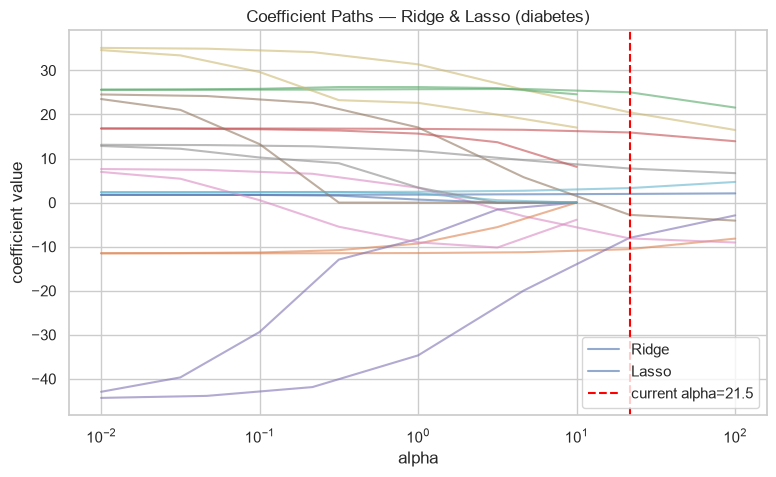

In [5]:
ridge_coefs, lasso_coefs = [], []
for a in reg["ridge_alphas"]:
    ridge_coefs.append(Ridge(alpha=a).fit(X_train, y_train).coef_)
for a in reg["lasso_alphas"]:
    lasso_coefs.append(Lasso(alpha=a, max_iter=10000).fit(X_train, y_train).coef_)

paths = {
    "Ridge": (reg["ridge_alphas"], ridge_coefs),
    "Lasso": (reg["lasso_alphas"], lasso_coefs),
}
fig = evaluation.plot_coefficient_paths(
    paths, current_alpha=reg["ridge"].best_params_["alpha"],
    title="Coefficient Paths — Ridge & Lasso (diabetes)")
plt.show()

## Part 2 — Ensemble Methods (breast_cancer)

We compare three classifiers by **F1 Score** and **AUC** on a held-out test set. Hyperparameters are tuned with 5-fold `GridSearchCV` (scoring = `f1`). AUC is computed from `predict_proba` (probabilities), not `predict`.

In [6]:
Xc_tr, Xc_te, yc_tr, yc_te, _, _ = data_loader.load_cancer_split()
clf = training.precompute_clf_results(Xc_tr, yc_tr)

rows = []
roc_data = {}
for name, gs in clf.items():
    best = gs.best_estimator_
    m = evaluation.classification_metrics(best, Xc_te, yc_te)
    rows.append({
        "Model": name,
        "Best params": gs.best_params_,
        "CV F1 (mean)": round(gs.best_score_, 4),
        "Test F1": round(m["f1"], 4),
        "Test AUC": round(m["auc"], 4) if m["auc"] is not None else None,
    })
    if hasattr(best, "predict_proba"):
        roc_data[name] = (yc_te, best.predict_proba(Xc_te)[:, 1])

results_clf = pd.DataFrame(rows)
display(results_clf)

,Model,Best params,CV F1 (mean),Test F1,Test AUC
0,DecisionTree,"{'max_depth': 5, 'min_samples_split': 5}",0.9518,0.9362,0.9163
1,RandomForest,"{'max_depth': 10, 'n_estimators': 100}",0.9634,0.9655,0.9939
2,GradientBoosting,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti...",0.9722,0.9660,0.9904


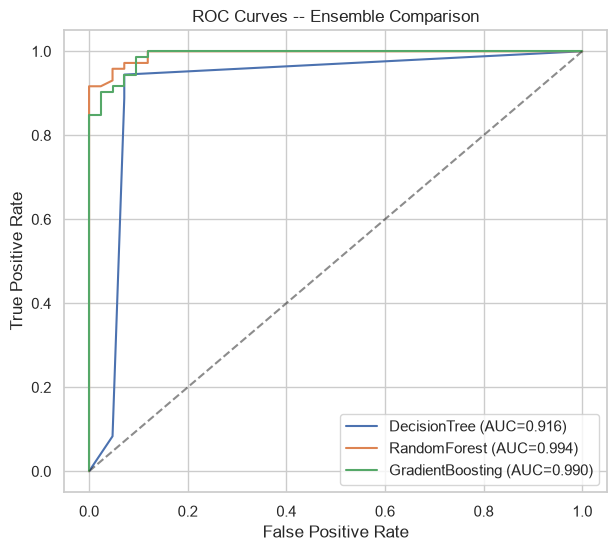

In [7]:
fig = evaluation.plot_roc_curves(roc_data)
plt.show()

## Findings & Credits

- **Regularization:** fill in after running — which model had the lowest test MSE, and what alpha was chosen?
- **Ensembles:** fill in after running — which classifier had the best F1 / AUC?

**Credits:** scikit-learn (`diabetes`, `breast_cancer` datasets); NTU PACE course notebooks `su-ntu-ctp/5m-data-3.4-supervised-learning-advanced`; scikit-learn user guide on `GridSearchCV`.